In [27]:
from collections import OrderedDict
import torchvision
import torch
from zipfile import ZipFile
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import numpy as np
import matplotlib.pyplot as plt


## Transforms With Params
Of Note: the below transform returns (1) A clean and augmented view of an image and (2) the mean-centered/unit-variance standardized parameters of the transformations applied to obtain the augmented view. Come to think of it, you could just normalize right before the regression step, but c'est la vie.

Subsequent cells define the dataset class (similar to `imagenet_100_dataloading.ipynb` example, and a helper function for getting the train/test datasets).

In [9]:
import torch
from torchvision.transforms import RandomResizedCrop, ToTensor
import numpy as np
from typing import List
from tqdm import tqdm
import matplotlib.pyplot as plt

from PIL import ImageOps, ImageFilter
from PIL import Image

import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import _interpolation_modes_from_int
import torchvision.transforms.functional as FT
from torchvision.transforms import ColorJitter, RandomResizedCrop


class RandomApplyGaussianBlur(object):
    def __init__(self, p: float, return_param: bool=True, min_sigma=0.1, max_sigma=2.0):
        super().__init__()
        self.p = p
        self.return_param = return_param
        self.min_sigma = min_sigma
        self.max_sigma = max_sigma

    def __call__(self, img):
        if np.random.rand() > self.p:
            if self.return_param:
                return img, 0.0, 0.0
            return img

        sigma = np.random.rand() * (self.max_sigma - self.min_sigma) + self.min_sigma 
        #sigma = np.random.rand() * 2.0
        if self.return_param:
            return img.filter(ImageFilter.GaussianBlur(sigma)), 1.0, sigma
  
        return img.filter(ImageFilter.GaussianBlur(sigma))

class RandomApplyGrayscale(object):
    def __init__(self, p: float, return_param: bool=True):
        super().__init__()
        self.p = p
        self.return_param = return_param

    def __call__(self, img):
        if np.random.rand() < self.p:
            g_img = FT.to_grayscale(img, num_output_channels=3)
            if self.return_param:
                return g_img, 1.0
            return g_img

        if self.return_param:
            return img, 0.0
        return img


class RandomApplySolarization(object):
    def __init__(self, p: float, return_param: bool=True):
        self.p = p
        self.return_param = return_param

    def __call__(self, img):
        if np.random.rand() > self.p:
            if self.return_param:
                return img, 0.0
            return img

        if self.return_param:
            return ImageOps.solarize(img), 1.0
        return ImageOps.solarize(img)
 
class RandomApplyHorizontalFlip(object):
    def __init__(self, p: float, return_param: bool=True):
        self.p = p
        self.return_param = return_param
    
    def __call__(self, img):
        if np.random.rand() > self.p:
            if self.return_param:
                return img, 0.0
            return img

        if self.return_param:
            return FT.hflip(img), 1.0
        return FT.hflip(img)


class RandomResizedCropWithParams(RandomResizedCrop):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.antialias = None

    def forward(self, img):
        H, W = FT.get_image_size(img)
        i, j, h, w = super().get_params(img, self.scale, self.ratio)

        return FT.resized_crop(img, i, j, h, w, self.size, self.interpolation), (i, j, h, w)

    
class ColorJiterWithParams(ColorJitter):
    def __init__(self, p, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.p = p

    def forward(self, img):
        if np.random.rand() < self.p:
            fn_idx, brightness_factor, contrast_factor, saturation_factor, hue_factor = self.get_params(
                self.brightness, self.contrast, self.saturation, self.hue
            )

            
            for fn_id in fn_idx:
                if fn_id == 0 and brightness_factor is not None:
                    img = FT.adjust_brightness(img, brightness_factor)
                elif fn_id == 1 and contrast_factor is not None:
                    img = FT.adjust_contrast(img, contrast_factor)
                elif fn_id == 2 and saturation_factor is not None:
                    img = FT.adjust_saturation(img, saturation_factor)
                elif fn_id == 3 and hue_factor is not None:
                    img = FT.adjust_hue(img, hue_factor)

            return img, (1.0, brightness_factor, contrast_factor, saturation_factor, hue_factor, fn_idx[0],fn_idx[1],fn_idx[2],fn_idx[3])
        return img, (0.0, 1.0, 1.0, 1.0, 0.0, 0., 1., 2., 3.)

class AlbumentationTransformWithParams(object):
    def __init__(self, normalize_params=True):
        super().__init__()

        self.normalize_params = normalize_params

        self.RRC = RandomResizedCropWithParams(scale=(0.08, 1.0), size=224, interpolation=Image.BICUBIC)
        self.GB1 = RandomApplyGaussianBlur(p=0.1)
        self.CJ = ColorJiterWithParams(
            p=0.8,
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.1
        )
        self.HF = RandomApplyHorizontalFlip(p=0.5)
        self.GS = RandomApplyGrayscale(p=0.2)

        self.ToTensor = transforms.ToTensor()
        self.Normalize = transforms.Normalize(
                        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                    )

        self.PARAM_STD = torch.tensor(
            [0.20667801, 0.20582265, 0.10378662, 0.05114949, 0.66197258,
            0.49992078, 0.40149222, 0.16650861, 0.21777757, 0.19287032,
            0.22679499]
        )

        self.PARAM_MEAN = torch.tensor(
        [ 9.97571434e-01,  1.00286493e+00,  9.99328507e-01, -1.10736424e-04,
        6.00240476e-01,  5.08900000e-01,  2.02000000e-01,
        1.54741821e-01,  2.44468570e-01,  5.94579496e-01,  6.93044198e-01]
        ) 

    def __call__(self, img):
        # spanning view
        clean_img = FT.resize(img, 256)
        clean_img = FT.center_crop(clean_img, 224)
        clean_tensor = self.ToTensor(clean_img)
        clean_tensor = self.Normalize(clean_tensor)

        # apply augmentations
        H, W = 224, 224
        crop, (i, j, h, w) = self.RRC(clean_img) 
        crop, hf = self.HF(crop)
        crop, (_, bri, con, sat, hue, _, _, _, _) = self.CJ(crop)
        crop, gs = self.GS(crop)
        crop, _, sigma = self.GB1(crop)
        crop = self.ToTensor(crop)
        crop = self.Normalize(crop)
        params = torch.tensor([bri, con, sat, hue, sigma, hf, gs, i / H, j / W, h / H, w / W])

        if self.normalize_params:
            params = (params - self.PARAM_MEAN) / self.PARAM_STD

        return (clean_tensor, crop), params

In [10]:
class Zip_ImageFolder(torchvision.datasets.ImageFolder):
    def __init__(self, zip_path, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.zip_path = zip_path
        self.zip_archvive = None

    def __getitem__(self, index: int):
        path, target = self.samples[index]
        if self.zip_archvive is None:
            self.zip_archvive = ZipFile(self.zip_path)

        path_split = path.split("/")
        fh = self.zip_archvive.open(
            path_split[-3] + "/" + path_split[-2] + "/" + path_split[-1]
        )

        image = Image.open(fh)
        sample = image.convert("RGB")

        if self.transform is not None:
            sample = self.transform(sample)

        if self.target_transform is not None:
            sample = self.target_transform(sample)

        return sample, target


In [20]:
imagenet_100_path = "/mnt/ceph/users/tyerxa/datasets/imagenet_100/"
def get_datasets_param_decoding():
    aug_with_params_test_data = Zip_ImageFolder(
                    zip_path=imagenet_100_path + "val.zip",
                    root=imagenet_100_path + "val/",
                    transform=AlbumentationTransformWithParams(
                        normalize_params=True,
                    ),
    )
    aug_with_params_train_data = Zip_ImageFolder(
                    zip_path=imagenet_100_path + "train.zip",
                    root=imagenet_100_path + "train/",
                    transform=AlbumentationTransformWithParams(
                        normalize_params=True, 
                    ),
    )

    return aug_with_params_train_data, aug_with_params_test_data

In [53]:
imagenet_normalize_mean = [0.485, 0.456, 0.406]
imagenet_normalize_std = [0.229, 0.224, 0.225]
class DeNormalizer(object):
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1)

    def __call__(self, img):
        return img * self.std + self.mean
imagenet_denormalizer = DeNormalizer(imagenet_normalize_mean, imagenet_normalize_std)

/tmp/ipykernel_1098664/2102732834.py:131: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  self.RRC = RandomResizedCropWithParams(scale=(0.08, 1.0), size=224, interpolation=Image.BICUBIC)
/mnt/home/tyerxa/miniconda3/envs/mmcr_clone/lib/python3.10/site-packages/torchvision/transforms/transforms.py:890: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  warnings.warn(


(-0.5, 223.5, 223.5, -0.5)

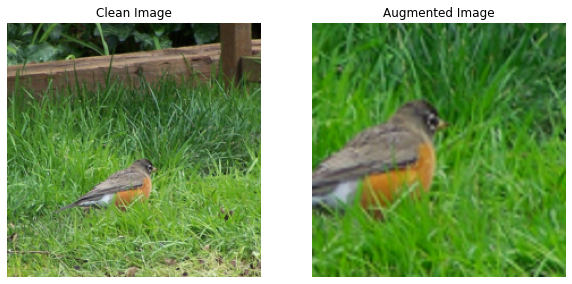

In [70]:
train_dataset, test_dataset = get_datasets_param_decoding()
sample =  test_dataset[0]
clean_img = sample[0][0][0]
aug_img = sample[0][0][1]

clean_img = imagenet_denormalizer(clean_img)
aug_img = imagenet_denormalizer(aug_img)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(clean_img.permute(1, 2, 0).numpy())
axs[0].set_title("Clean Image")
axs[0].axis("off")

axs[1].imshow(aug_img.permute(1, 2, 0).numpy())
axs[1].set_title("Augmented Image")
axs[1].axis("off")


## Feature Extraction

- load a pair of models
- extract features in response to clean/augmented views for each

In [22]:
def extract_features_param_decoding(model_1, model_2, loader, num_batches=None):
    if num_batches is None:
        num_batches = len(loader)

    responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2,  = [], [], [], []
    params, labels = [], []
    n_ = 0
    for ((clean_image, augmented_image), param), label in tqdm(loader):
        with torch.no_grad():
            clean_image = clean_image.cuda()
            augmented_image = augmented_image.cuda()
            responses_clean_1.append(model_1(clean_image).cpu())
            responses_augmented_1.append(model_1(augmented_image).cpu())
            responses_clean_2.append(model_2(clean_image).cpu())
            responses_augmented_2.append(model_2(augmented_image).cpu())

            params.append(param)
            labels.append(label)
        n_ += 1
        if n_ == num_batches:
            break

    responses_clean_1 = torch.cat(responses_clean_1)
    responses_augmented_1 = torch.cat(responses_augmented_1)
    responses_clean_2 = torch.cat(responses_clean_2)
    responses_augmented_2 = torch.cat(responses_augmented_2)

    params = torch.cat(params)
    labels = torch.cat(labels)

    return responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2, params, labels

In [15]:
def _load_composer_classifier_r50(sd):
    """
    Load a model saved via Composer into a vanilla torchvision model.
    """
    model = torchvision.models.resnet.resnet50()
    new_sd = OrderedDict()
    for k, v in sd.items():
        if 'lin_cls' in k:
            new_sd['fc.' + k.split('.')[-1]] = v
        if ".f." not in k:
            continue
        parts = k.split(".")
        idx = parts.index("f")
        new_k = ".".join(parts[idx + 1 :])
        new_sd[new_k] = v
    model.load_state_dict(new_sd, strict=True)
    return model.eval()

In [18]:
# Model Loading
path_model_invariant = '/mnt/ceph/users/tyerxa/equi_proj/training_checkpoints/final/resnet_50/Barlow/lmda_0.0/ep100-ba62500-rank0'
path_model_equivariant = '/mnt/ceph/users/tyerxa/equi_proj/training_checkpoints/final/resnet_50/Barlow/lmda_0.3/ep100-ba62500-rank0'

r50_invariant = torchvision.models.resnet50()
r50_equivariant = torchvision.models.resnet50()

sd_invariant = torch.load(path_model_invariant, map_location='cpu')["state"]["model"]
sd_equivariant = torch.load(path_model_equivariant, map_location='cpu')["state"]["model"]

r50_invariant = _load_composer_classifier_r50(sd_invariant)
r50_equivariant = _load_composer_classifier_r50(sd_equivariant)

# finally, lets remove the linear classifier 
r50_invariant.fc = torch.nn.Identity()
r50_equivariant.fc = torch.nn.Identity()

r50_invariant = r50_invariant.cuda().eval()
r50_equivariant = r50_equivariant.cuda().eval()

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
)


/tmp/ipykernel_1098664/2102732834.py:131: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  self.RRC = RandomResizedCropWithParams(scale=(0.08, 1.0), size=224, interpolation=Image.BICUBIC)
/mnt/home/tyerxa/miniconda3/envs/mmcr_clone/lib/python3.10/site-packages/torchvision/transforms/transforms.py:890: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  warnings.warn(


In [25]:
# Extract Features
rc_test_1, ra_test_1, rc_test_2, ra_test_2, params_test, labels_test = extract_features_param_decoding(
    r50_invariant, 
    r50_equivariant, 
    test_loader
)
rc_train_1, ra_train_1, rc_train_2, ra_train_2, params_train, labels_train = extract_features_param_decoding(
    r50_invariant, 
    r50_equivariant, 
    train_loader
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████▉| 989/990 [04:28<00:00,  3.68it/s]


## Evaluation/Visualization

In [28]:
X1_train = torch.cat([rc_train_1, ra_train_1], dim=1).detach().cpu().numpy()
X2_train = torch.cat([rc_train_2, ra_train_2], dim=1).detach().cpu().numpy()

X1_test = torch.cat([rc_test_1, ra_test_1], dim=1).detach().cpu().numpy()
X2_test = torch.cat([rc_test_2, ra_test_2], dim=1).detach().cpu().numpy()

Y_train = params_train.detach().cpu().numpy()
Y_test = params_test.detach().cpu().numpy()

regression_1 = LinearRegression().fit(X1_train, Y_train)
regression_2 = LinearRegression().fit(X2_train, Y_train)

score_1 = regression_1.score(X1_test, Y_test)
score_2 = regression_2.score(X2_test, Y_test)

preds_1 = regression_1.predict(X1_test)
preds_2 = regression_2.predict(X2_test)

In [41]:
# can additionally score on each augmentation individually
AUGMENTATION_LIST = ["Brightness", "Contrast", "Saturation", "Hue", "Sigma", "Flip", "Grayscale", "X", "Y", "XScale", "YScale"]

r2_invariant, r2_equivariant = {}, {}
for _ in range(len(AUGMENTATION_LIST)):
    r2_invariant[AUGMENTATION_LIST[_]] =  r2_score(Y_test[:, _], preds_1[:, _])
    r2_equivariant[AUGMENTATION_LIST[_]] =  r2_score(Y_test[:, _], preds_2[:, _])

Invariant Score: 0.442, Equivariant Score: 0.700


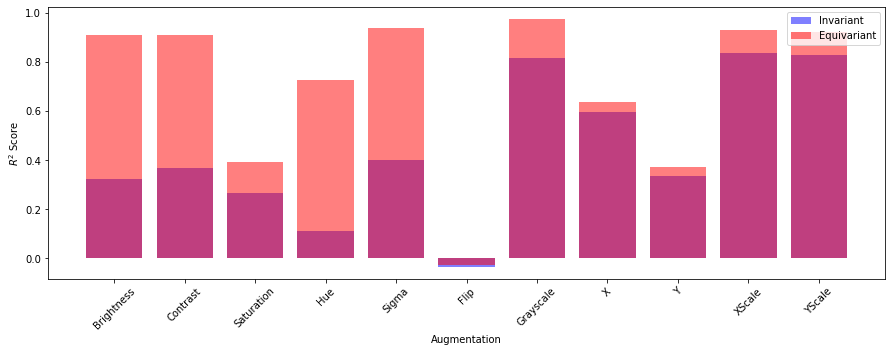

In [43]:
print(f"Invariant Score: {score_1:.3f}, Equivariant Score: {score_2:.3f}")
plt.figure(figsize=(15, 5))
plt.bar(r2_invariant.keys(), r2_invariant.values(), color='blue', alpha=0.5, label='Invariant')
plt.bar(r2_equivariant.keys(), r2_equivariant.values(), color='red', alpha=0.5, label='Equivariant')
plt.xticks(rotation=45)
plt.xlabel('Augmentation')
plt.ylabel('$R^2$ Score')

plt.legend()